# Breast Cancer Diagnosis using Machine Learning

---

## Project Overview

Breast cancer is one of the most common cancers affecting women worldwide and remains a leading cause of cancer-related mortality. Early diagnosis plays a critical role in improving treatment outcomes and patient survival.

In this project, multiple machine learning techniques will be developed and evaluated to classify breast tumors as **benign** or **malignant** using clinical features extracted from digitized fine needle aspiration (FNA) images.

Unlike the previous projects, this notebook places greater emphasis on **model interpretation**, **feature selection**, **validation techniques**, and **explainable artificial intelligence (XAI)** in addition to predictive performance.

---

## Learning Outcomes

By the end of this project, I will be able to:

- Understand the clinical background of breast cancer diagnosis.
- Perform advanced exploratory data analysis.
- Identify relationships between clinical features.
- Apply feature selection techniques.
- Train and compare multiple machine learning models.
- Understand learning curves and validation curves.
- Explain model predictions using SHAP.
- Interpret model performance from a clinical perspective.

# Clinical Importance of Early Detection

Early detection is one of the most important factors influencing breast cancer prognosis. Tumors identified at an early stage are generally smaller, less likely to have metastasized, and can often be treated with less aggressive therapies.

Machine learning has the potential to assist clinicians by identifying subtle patterns within clinical data that may be difficult to recognize manually. Such models can support early diagnosis, improve consistency in decision-making, and ultimately contribute to better patient outcomes.

In [3]:
from sklearn.datasets import load_breast_cancer

breast = load_breast_cancer()

print(breast.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


# Loading the Dataset

The Breast Cancer Wisconsin Diagnostic Dataset is included within Scikit-learn and contains measurements extracted from digitized images of fine needle aspiration (FNA) of breast masses.

Each row represents one tumor sample, while each column corresponds to a quantitative feature describing the characteristics of the cell nuclei.

The objective is to classify each tumor as **benign** or **malignant** based on these measurements.

In [4]:
import pandas as pd

# Create feature DataFrame
df = pd.DataFrame(
    breast.data,
    columns=breast.feature_names
)

# Add target column
df["target"] = breast.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# Understanding the Dataset

The dataset consists of **30 numerical features** describing morphological characteristics of breast tumor cells extracted from digitized Fine Needle Aspiration (FNA) images.

These measurements capture properties such as tumor size, texture, perimeter, smoothness, compactness, symmetry, and fractal characteristics.

The target variable represents the clinical diagnosis of the tumor:

- **0 → Malignant**
- **1 → Benign**

Understanding the dataset is essential before performing exploratory data analysis or building predictive models.

In [5]:
# Dataset dimensions
df.shape

# Data types
df.info()

# Summary statistics
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


# Class Distribution

Before building any machine learning model, it is important to understand the distribution of the target classes.

Class imbalance can influence model training and evaluation. If one class is much more common than the other, a model may appear to perform well simply by predicting the majority class.

Therefore, we first examine the number of benign and malignant tumors in the dataset.

In [6]:
# Count the number of samples in each class
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [7]:
# Percentage distribution
df["target"].value_counts(normalize=True) * 100

target
1    62.741652
0    37.258348
Name: proportion, dtype: float64

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is an essential step in every machine learning project. It helps us understand the characteristics of the dataset before building predictive models.

In this section, we will:

- Examine the distribution of the target classes.
- Explore the distribution of important clinical features.
- Investigate relationships between variables.
- Identify highly correlated features.
- Gain insights that will guide feature selection and model development.

## Class Distribution

Understanding the class distribution is important because highly imbalanced datasets can bias machine learning models toward the majority class.

The following visualization illustrates the number of benign and malignant tumors in the dataset.

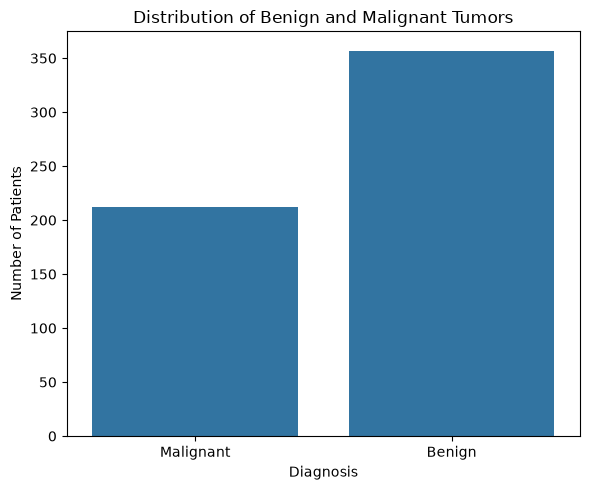

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="target"
)

plt.xticks(
    ticks=[0,1],
    labels=["Malignant", "Benign"]
)

plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.title("Distribution of Benign and Malignant Tumors")

plt.tight_layout()

plt.savefig(
    "../figures/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Pairwise Feature Relationships

Pairplots provide a visual representation of the relationships between multiple numerical features.

They are useful for identifying natural class separation, detecting correlated variables, and gaining intuition about which features may contribute most to classification.

Since the dataset contains 30 features, only a small subset of clinically meaningful variables is selected for visualization to maintain readability.

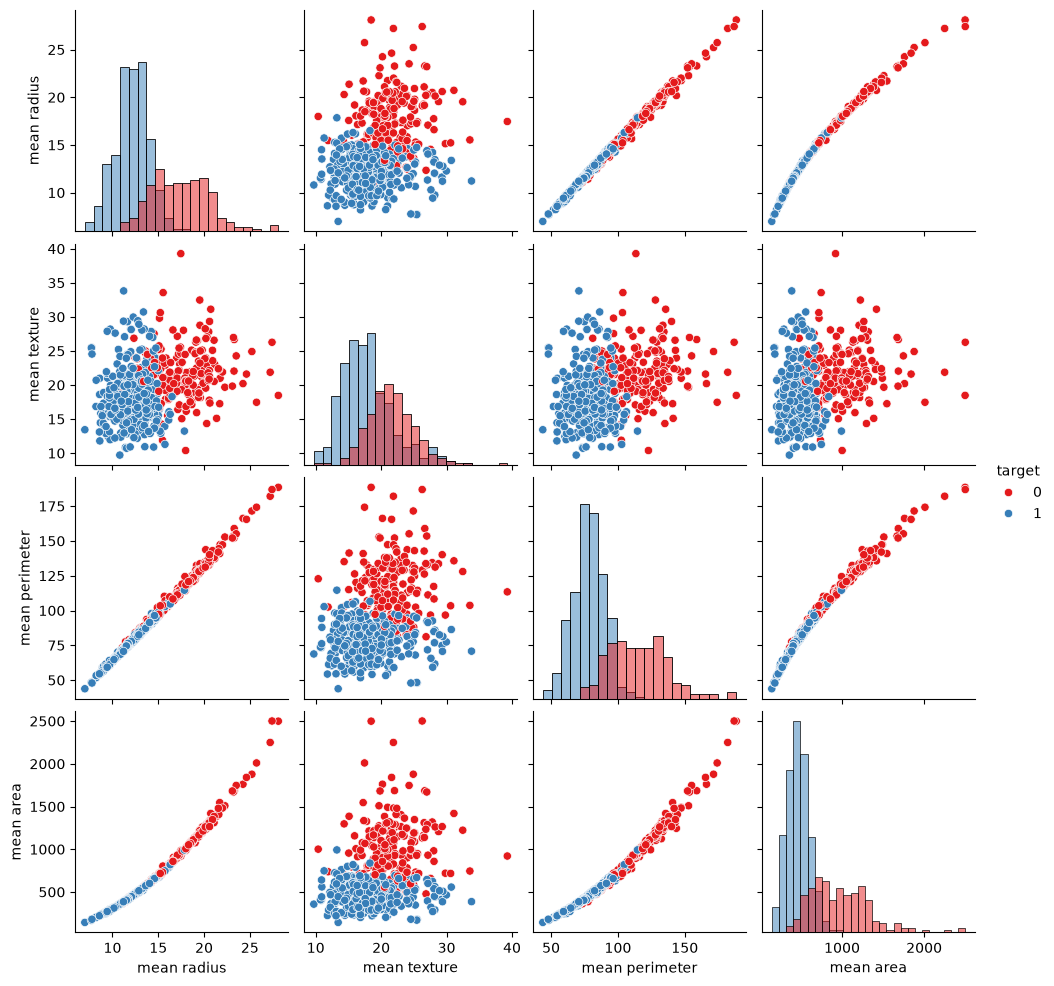

In [9]:
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "target"
]

sns.pairplot(
    df[selected_features],
    hue="target",
    palette="Set1",
    diag_kind="hist"
)

plt.savefig(
    "../figures/pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The pairplot reveals several important characteristics of the dataset.

- Tumors with larger values for **mean radius**, **mean perimeter**, and **mean area** are more likely to be malignant.
- Benign tumors are generally clustered around smaller values for these features.
- Several feature pairs exhibit a clear separation between benign and malignant tumors, suggesting that these variables have strong predictive value.
- Strong linear relationships are also observed between **mean radius**, **mean perimeter**, and **mean area**, indicating that these features may contain overlapping information.

These observations suggest that some variables are highly informative for classification, while others may be redundant. This motivates the use of **correlation analysis** and **feature selection** in the subsequent stages of the project.

# Correlation Analysis

Correlation analysis quantifies the relationship between numerical features.

Highly correlated variables often contain similar information, leading to redundancy in machine learning models. Identifying these relationships helps simplify models, improve interpretability, and supports effective feature selection.

It is important to remember that **correlation does not imply causation**. Two variables may be strongly correlated without one causing the other.

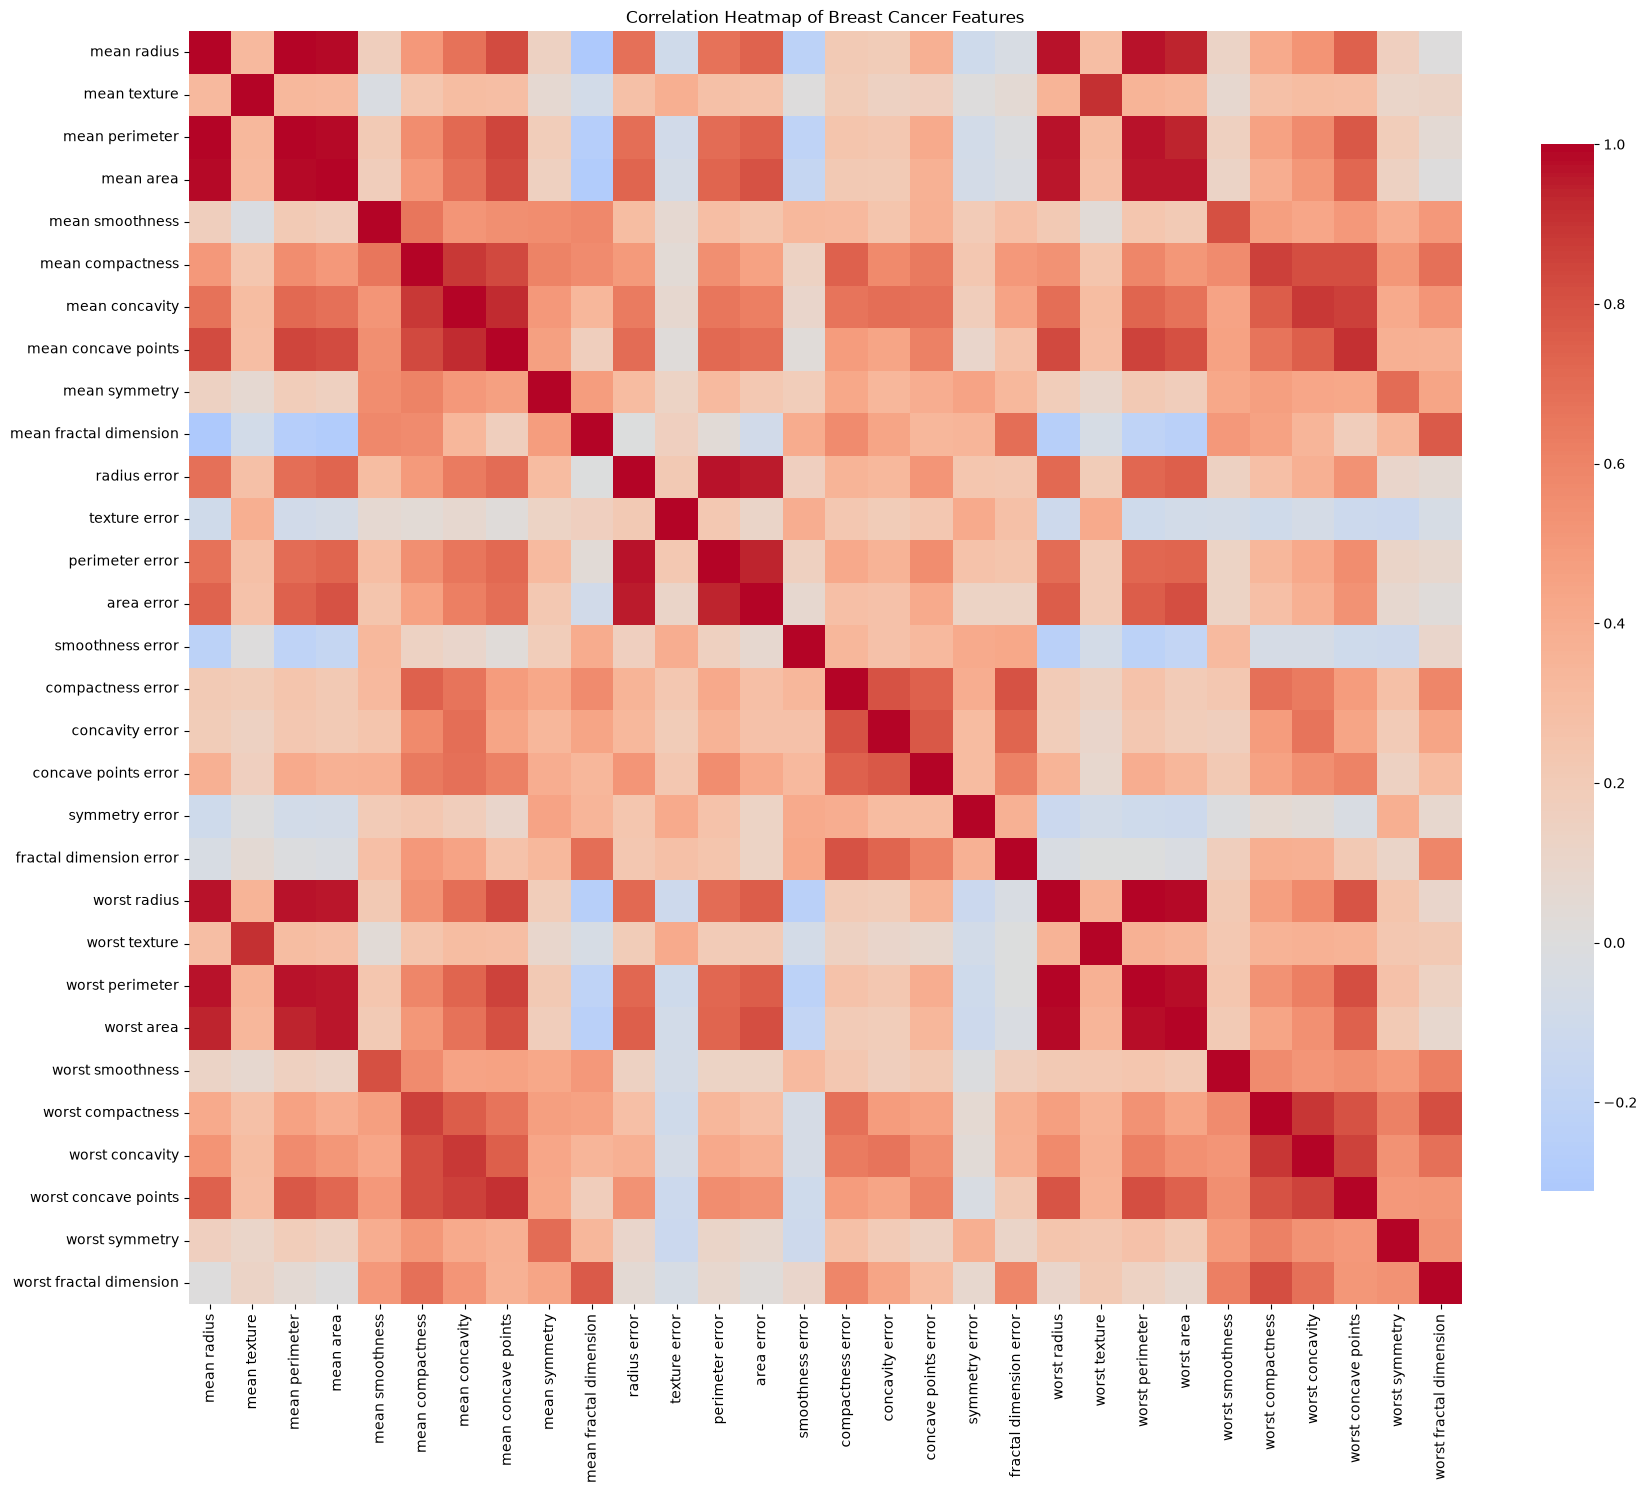

In [10]:
plt.figure(figsize=(18, 15))

correlation_matrix = df.drop("target", axis=1).corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap of Breast Cancer Features")

plt.tight_layout()

plt.savefig(
    "../figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Feature Selection

Feature Selection is the process of identifying the most informative predictor variables while removing irrelevant or redundant features.

Selecting an appropriate subset of features can simplify machine learning models, reduce computational cost, improve interpretability, and help reduce overfitting.

In this project, multiple feature selection techniques will be explored and compared.

# Feature Selection Technique 1: Variance Threshold

Variance Threshold is one of the simplest feature selection techniques.

It removes features that exhibit little or no variation across the dataset. Features with very low variance are unlikely to contribute meaningful information for distinguishing between different classes.

Unlike many other feature selection techniques, Variance Threshold is **unsupervised**, as it only considers the predictor variables and ignores the target labels.

In [11]:
from sklearn.feature_selection import VarianceThreshold

# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

# Initialize Variance Threshold
selector = VarianceThreshold(threshold=0.01)

# Fit and transform the features
X_variance = selector.fit_transform(X)

print("Original number of features:", X.shape[1])
print("Remaining features:", X_variance.shape[1])

Original number of features: 30
Remaining features: 14


In [12]:
# Features that were kept
selected_features = X.columns[selector.get_support()]

print("Selected Features:\n")

for feature in selected_features:
    print(feature)

Selected Features:

mean radius
mean texture
mean perimeter
mean area
radius error
texture error
perimeter error
area error
worst radius
worst texture
worst perimeter
worst area
worst compactness
worst concavity


# Feature Selection Technique 2: SelectKBest

Unlike Variance Threshold, SelectKBest is a **supervised** feature selection method.

It evaluates each feature individually using a statistical test and ranks features according to how strongly they are associated with the target variable.

The top **K** highest-scoring features are then selected for further analysis.

In [13]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select the 10 best features
selector = SelectKBest(score_func=f_classif, k=10)

X_selected = selector.fit_transform(X, y)

print("Original Features:", X.shape[1])
print("Selected Features:", X_selected.shape[1])

Original Features: 30
Selected Features: 10


### Feature Importance Scores

SelectKBest assigns each feature a statistical score representing its relationship with the target variable.

Features with higher scores are considered more informative for predicting whether a tumor is benign or malignant.

In [14]:
feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

feature_scores = feature_scores.sort_values(
    by="Score",
    ascending=False
)

feature_scores.head(10)

,Feature,Score
27,worst concave points,964.385393
22,worst perimeter,897.944219
7,mean concave points,861.676020
20,worst radius,860.781707
2,mean perimeter,697.235272
23,worst area,661.600206
0,mean radius,646.981021
3,mean area,573.060747
6,mean concavity,533.793126
26,worst concavity,436.691939


### Top Features Identified by SelectKBest

The following figure displays the ten highest-scoring features according to the ANOVA F-test used by SelectKBest.

Higher scores indicate a stronger statistical association with the diagnosis.

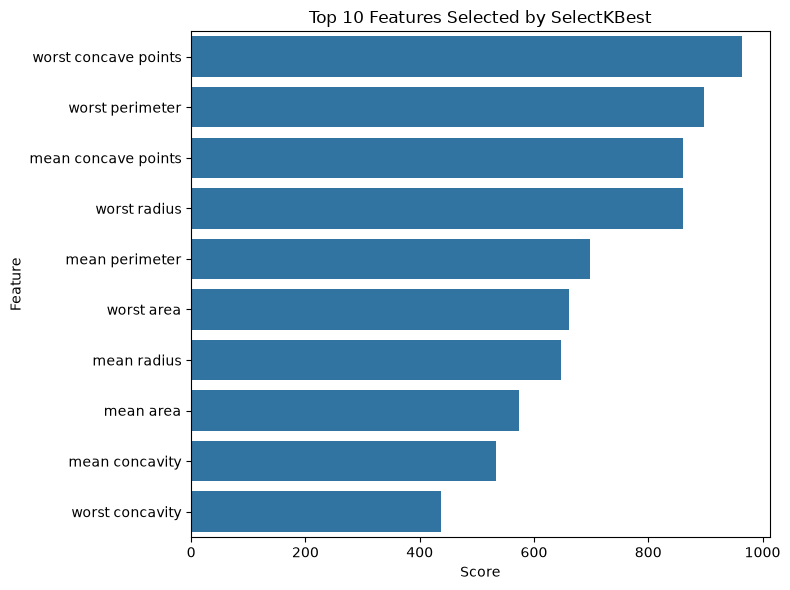

In [15]:
top10 = feature_scores.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10,
    x="Score",
    y="Feature"
)

plt.title("Top 10 Features Selected by SelectKBest")

plt.tight_layout()

plt.savefig(
    "../figures/selectkbest_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Feature Selection Technique 3: Recursive Feature Elimination (RFE)

Recursive Feature Elimination (RFE) is a wrapper-based feature selection technique.

It begins with all available features, trains a machine learning model, removes the least important feature, and repeats the process until the desired number of features remains.

Unlike filter methods such as Variance Threshold and SelectKBest, RFE evaluates features based on their contribution to a predictive model.

In [16]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Initialize the model
model = LogisticRegression(max_iter=10000)

# Select the top 10 features
rfe = RFE(estimator=model, n_features_to_select=10)

# Fit RFE
X_rfe = rfe.fit_transform(X, y)

print("Original Features:", X.shape[1])
print("Selected Features:", X_rfe.shape[1])

Original Features: 30
Selected Features: 10


In [17]:
selected_features = X.columns[rfe.support_]

print("Features Selected by RFE:\n")

for feature in selected_features:
    print(feature)

Features Selected by RFE:

mean radius
mean compactness
mean concavity
texture error
worst radius
worst smoothness
worst compactness
worst concavity
worst concave points
worst symmetry


### Features Selected by RFE

The Recursive Feature Elimination algorithm identified the ten features that contributed most to the Logistic Regression model.

Unlike statistical filter methods, these features were selected based on their ability to improve predictive performance when considered together.

# Feature Selection Technique 4: Tree-Based Feature Importance

Tree-based models, such as Random Forests, provide an embedded method for feature selection.

During training, the model evaluates how much each feature contributes to improving the quality of decision splits.

Features with higher importance scores have a greater influence on the model's predictions and are considered more informative.

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest model
rf = RandomForestClassifier(random_state=42)

rf.fit(X, y)

# Create a DataFrame of feature importances
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
23,worst area,0.139357
27,worst concave points,0.132225
7,mean concave points,0.107046
20,worst radius,0.082848
22,worst perimeter,0.080850
2,mean perimeter,0.067990
6,mean concavity,0.066917
3,mean area,0.060462
26,worst concavity,0.037339
0,mean radius,0.034843


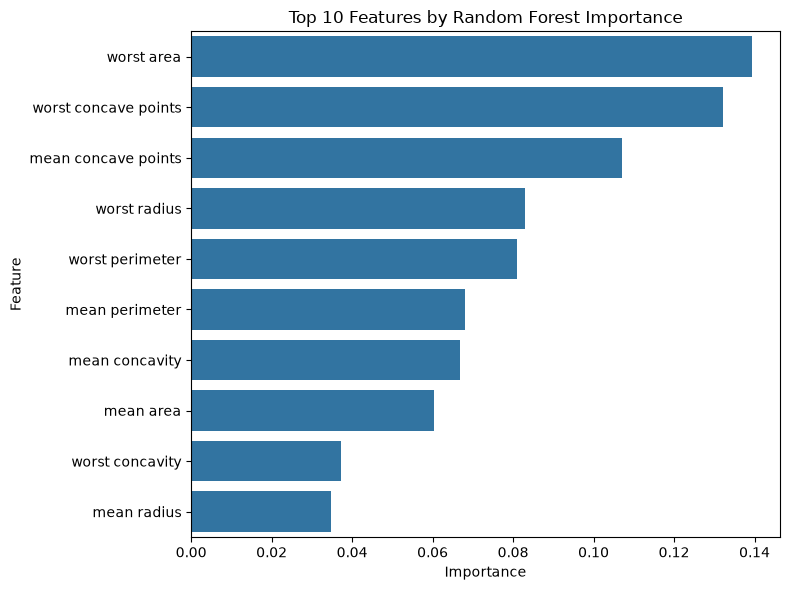

In [19]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features by Random Forest Importance")

plt.tight_layout()

plt.savefig(
    "../figures/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Training the model to use the features

In [20]:
from sklearn.model_selection import train_test_split

# Separate predictors and target
X = df.drop("target", axis=1)
y = df["target"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


# Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification problems.

Instead of predicting a continuous value, it estimates the probability that an observation belongs to a particular class. Due to its simplicity, interpretability, and strong performance on structured datasets, it is commonly used as a baseline classification model in healthcare research.

In [21]:
from sklearn.linear_model import LogisticRegression

# Initialize the model
log_reg = LogisticRegression(max_iter=10000, random_state=42)

# Train the model
log_reg.fit(X_train, y_train)

# Make predictions
y_pred = log_reg.predict(X_test)

# Model Evaluation

After training a machine learning model, its performance must be evaluated on unseen test data.

The first evaluation metric is **Accuracy**, which measures the proportion of correctly classified samples among all predictions.

Although accuracy is easy to understand, it can be misleading for imbalanced medical datasets. Therefore, additional metrics such as precision, recall, F1-score, and ROC-AUC will also be considered.

In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9649


In [23]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


## Confusion Matrix

A confusion matrix provides a detailed breakdown of the model's predictions by comparing the predicted labels with the true labels.

Unlike accuracy, it allows us to identify the types of errors made by the model, such as missed cancer cases (False Negatives) or incorrectly predicted cancer cases (False Positives).

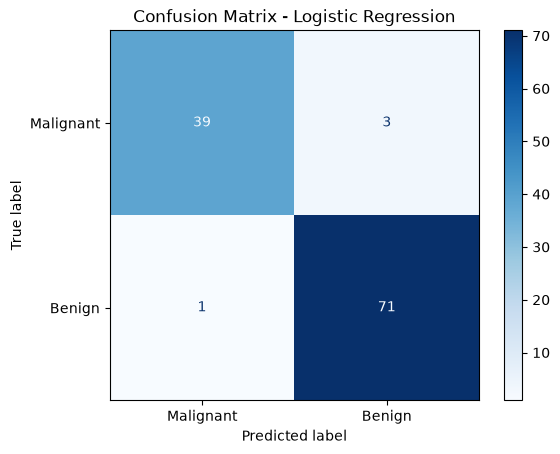

[[39  3]
 [ 1 71]]


In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

print(cm)

### Interpretation of the Confusion Matrix

The Logistic Regression model correctly identified **39 malignant tumors** and **71 benign tumors**.

However, it incorrectly classified **3 malignant tumors as benign (False Negatives)** and **1 benign tumor as malignant (False Positive)**.

In clinical practice, False Negatives are generally considered the more serious error because they may delay diagnosis and treatment of patients with cancer.


# Precision

Precision measures the proportion of predicted positive cases that are truly positive.

A high precision indicates that when the model predicts a patient has the disease, it is usually correct.

Precision is particularly important in situations where False Positives lead to unnecessary interventions or additional medical procedures.

In [25]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")

Precision: 0.9595


# Recall (Sensitivity)

Recall, also known as Sensitivity or the True Positive Rate, measures the proportion of actual positive cases that are correctly identified by the model.

A high recall indicates that the model misses very few patients with the disease.

In healthcare applications, recall is often considered one of the most important evaluation metrics because reducing False Negatives can lead to earlier diagnosis and treatment.

In [26]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print(f"Recall: {recall:.4f}")

Recall: 0.9861


# F1-Score

The F1-score combines Precision and Recall into a single evaluation metric.

It is particularly useful when there is a need to balance False Positives and False Negatives.

A high F1-score indicates that the model achieves both high precision and high recall.

In [27]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print(f"F1-score: {f1:.4f}")

F1-score: 0.9726


# Classification Report

The classification report summarizes the performance of the classification model by reporting Precision, Recall, F1-score, and Support for each class.

It provides a comprehensive overview of the model's predictive performance.

In [28]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Malignant", "Benign"]
    )
)

              precision    recall  f1-score   support

   Malignant       0.97      0.93      0.95        42
      Benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# ROC Curve and AUC

The Receiver Operating Characteristic (ROC) Curve evaluates the performance of a classification model across different probability thresholds.

It illustrates the trade-off between the True Positive Rate (Sensitivity) and the False Positive Rate.

The Area Under the Curve (AUC) summarizes the model's ability to distinguish between the positive and negative classes.

A larger AUC indicates better discriminative performance.

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of the positive class (Benign in this dataset)
y_prob = log_reg.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc = roc_auc_score(y_test, y_prob)

print(f"AUC: {auc:.4f}")

AUC: 0.9954


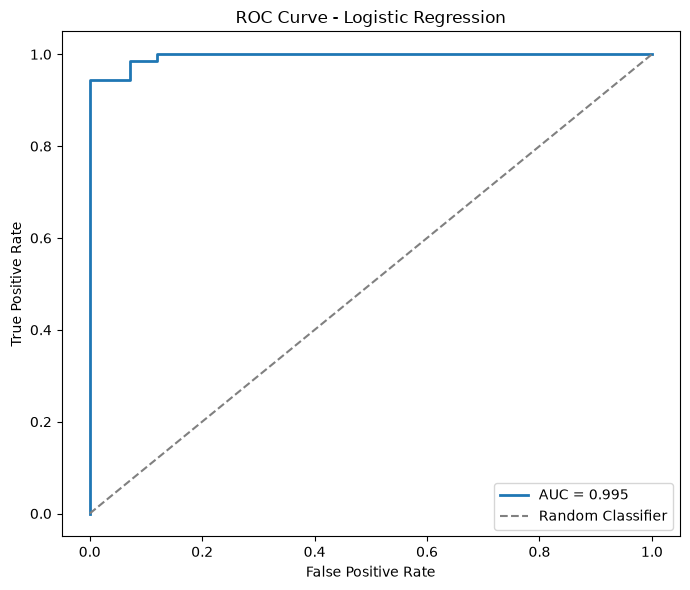

In [30]:
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", linewidth=2)
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")

plt.tight_layout()

# Save the figure
plt.savefig(
    "../figures/logistic_regression_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Decision Tree Classifier

A Decision Tree is a supervised machine learning algorithm used for classification and regression tasks.

It learns by recursively splitting the dataset into smaller subsets based on feature values that best separate the classes.

Decision Trees are highly interpretable because the decision-making process can be visualized as a sequence of if-then rules.

However, deep trees are prone to overfitting and may not generalize well to unseen data.

In [31]:
selected_features_rfe = X.columns[rfe.support_]

print(selected_features_rfe)

Index(['mean radius', 'mean compactness', 'mean concavity', 'texture error',
       'worst radius', 'worst smoothness', 'worst compactness',
       'worst concavity', 'worst concave points', 'worst symmetry'],
      dtype='str')


In [32]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the model
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt.predict(X_test)

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Decision Tree Performance")
print("-" * 30)

print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_dt):.4f}")

Decision Tree Performance
------------------------------
Accuracy : 0.9123
Precision: 0.9559
Recall   : 0.9028
F1-score : 0.9286


In [34]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=["Malignant", "Benign"]
    )
)

              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



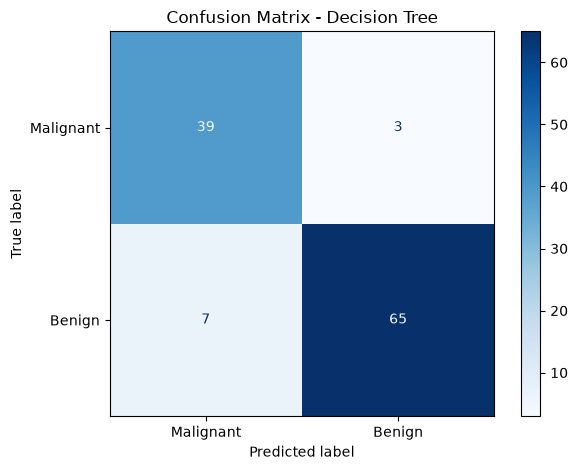

[[39  3]
 [ 7 65]]


In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Malignant", "Benign"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")

plt.tight_layout()

plt.savefig(
    "../figures/decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(cm_dt)

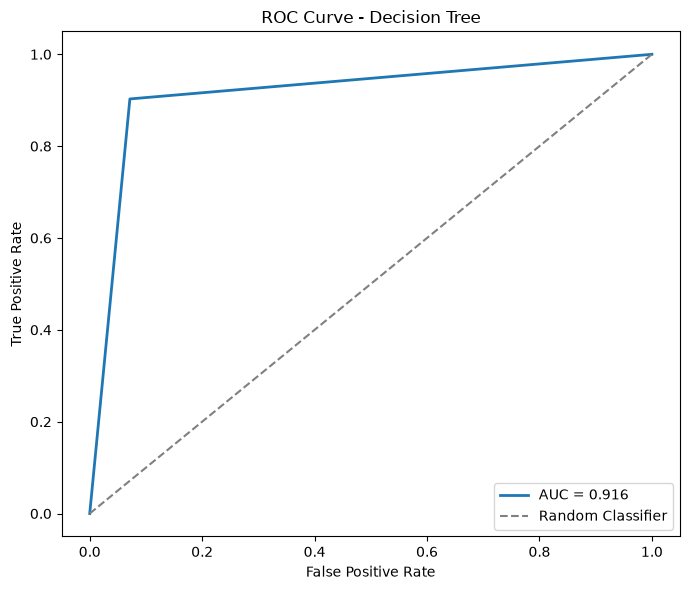

AUC: 0.9157


In [36]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_dt = dt.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

plt.figure(figsize=(7,6))

plt.plot(fpr_dt, tpr_dt, label=f"AUC = {auc_dt:.3f}", linewidth=2)
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(
    "../figures/decision_tree_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"AUC: {auc_dt:.4f}")

## Comparison: Logistic Regression vs Decision Tree

The Decision Tree classifier achieved good predictive performance; however, it did not outperform Logistic Regression.

Both models correctly identified the same number of malignant tumors, but the Decision Tree produced more False Positive predictions. Consequently, more patients with benign tumors would undergo unnecessary follow-up investigations.

Overall, Logistic Regression demonstrated superior accuracy, F1-score, and AUC, making it the stronger baseline model for this dataset.

# Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple Decision Trees to improve predictive performance.

Each Decision Tree is trained on a different random subset of the training data and considers a random subset of features at each split.

The final prediction is determined through majority voting for classification tasks.

Compared with a single Decision Tree, Random Forest generally provides better accuracy, improved generalization, and reduced overfitting.

In [37]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf.predict(X_test)

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Random Forest Performance")
print("-" * 35)

print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_rf):.4f}")

Random Forest Performance
-----------------------------------
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1-score : 0.9655


In [39]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Malignant", "Benign"]
    )
)

              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



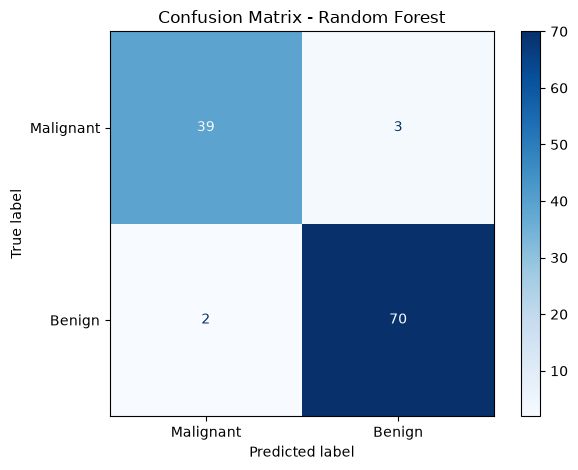

[[39  3]
 [ 2 70]]


In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Malignant", "Benign"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")

plt.tight_layout()

plt.savefig(
    "../figures/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(cm_rf)

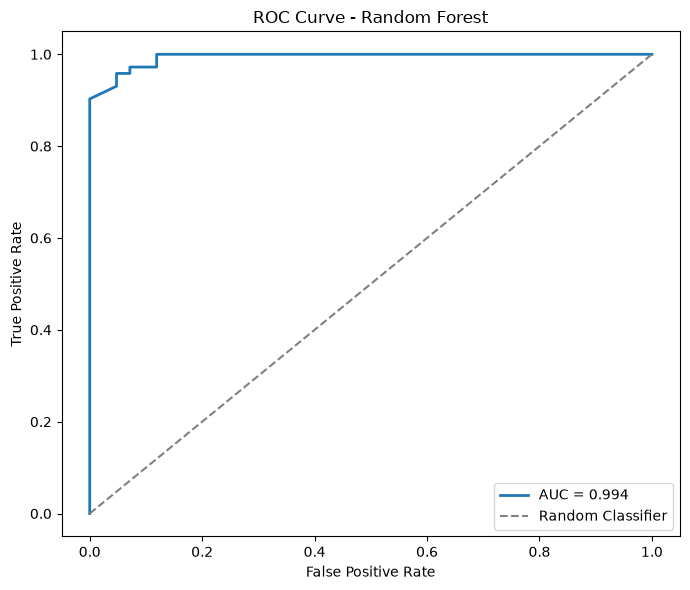

AUC: 0.9937


In [41]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_rf = rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7,6))

plt.plot(fpr_rf, tpr_rf, label=f"AUC = {auc_rf:.3f}", linewidth=2)
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(
    "../figures/random_forest_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"AUC: {auc_rf:.4f}")

## Model Comparison

Three machine learning algorithms were evaluated for breast cancer classification: Logistic Regression, Decision Tree, and Random Forest.

Among the evaluated models, Logistic Regression achieved the highest overall performance across all evaluation metrics, including Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Although Random Forest also demonstrated excellent predictive performance, it produced slightly more False Positive predictions than Logistic Regression. In contrast, the Decision Tree exhibited the lowest overall performance and generated the highest number of False Positives.

Overall, Logistic Regression was selected as the best-performing model for this dataset.

# Feature Importance

Random Forest estimates the importance of each feature by measuring how much it contributes to reducing impurity across all Decision Trees in the forest.

Features with higher importance values contribute more to the model's predictions.

Feature importance improves model interpretability by identifying which variables were most influential during classification.

It is important to note that feature importance reflects predictive value rather than causal relationships.

In [42]:
# Create a DataFrame of feature importances
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
23,worst area,0.140016
27,worst concave points,0.129530
20,worst radius,0.097696
7,mean concave points,0.090885
22,worst perimeter,0.072226
2,mean perimeter,0.069574
0,mean radius,0.068676
6,mean concavity,0.057638
3,mean area,0.049172
26,worst concavity,0.034340


## Feature Importance

The Random Forest model ranked features according to their contribution to reducing impurity during the decision-making process.

The visualization highlights the ten most influential features used by the model for breast cancer classification.

These features provide insight into the variables that contributed most strongly to the model's predictions, although they should not be interpreted as causal factors.

## Interpretation of Feature Importance

The Random Forest model identified features related to tumor size and boundary irregularity as the most influential predictors of breast cancer classification.

Among all variables, **Worst Area** had the highest importance score, followed by **Worst Concave Points** and **Worst Radius**.

These findings are clinically meaningful, as malignant tumors generally exhibit larger sizes and more irregular boundaries than benign tumors.

Although feature importance improves model interpretability, these importance scores represent predictive contribution rather than causal relationships.

# Comparison of Feature Selection Methods

Three feature selection approaches were evaluated in this project:

- SelectKBest
- Recursive Feature Elimination (RFE)
- Random Forest Feature Importance

Although each method uses a different strategy to identify relevant features, several biomarkers were consistently selected across multiple approaches.

The agreement between different feature selection techniques increases confidence that these variables are genuinely informative for breast cancer classification.

In [43]:
comparison = pd.DataFrame({
    "SelectKBest": selected_features,
    "RFE": selected_features_rfe,
    "Random Forest Top Features": feature_importance["Feature"].head(10).values
})

comparison

,SelectKBest,RFE,Random Forest Top Features
0,mean radius,mean radius,worst area
1,mean compactness,mean compactness,worst concave points
2,mean concavity,mean concavity,worst radius
3,texture error,texture error,mean concave points
4,worst radius,worst radius,worst perimeter
5,worst smoothness,worst smoothness,mean perimeter
6,worst compactness,worst compactness,mean radius
7,worst concavity,worst concavity,mean concavity
8,worst concave points,worst concave points,mean area
9,worst symmetry,worst symmetry,worst concavity


# Explainable AI using SHAP

SHAP (SHapley Additive exPlanations) is an Explainable AI (XAI) technique that explains the predictions of machine learning models.

Unlike traditional feature importance, SHAP can provide both global explanations (which features are important overall) and local explanations (why the model made a specific prediction for an individual patient).

This improves model transparency and helps clinicians understand the reasoning behind AI-assisted decisions.

In [50]:
import shap

# Create the explainer
explainer = shap.Explainer(rf)

# Generate explanations
shap_values = explainer(X_test)

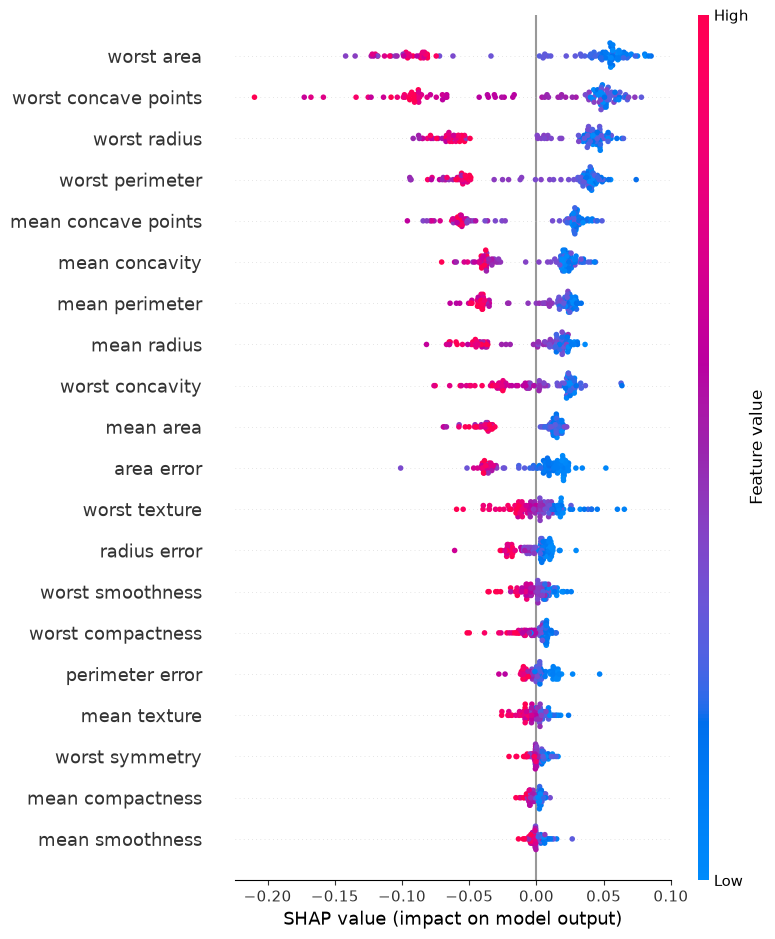

In [51]:
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../figures/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## SHAP Summary Plot

The SHAP summary plot provides a global explanation of the model by showing which features have the greatest influence on predictions across all patients.

Each point represents one patient, while the color indicates the feature value (red = high, blue = low). Features are ranked according to their overall impact on the model's predictions.

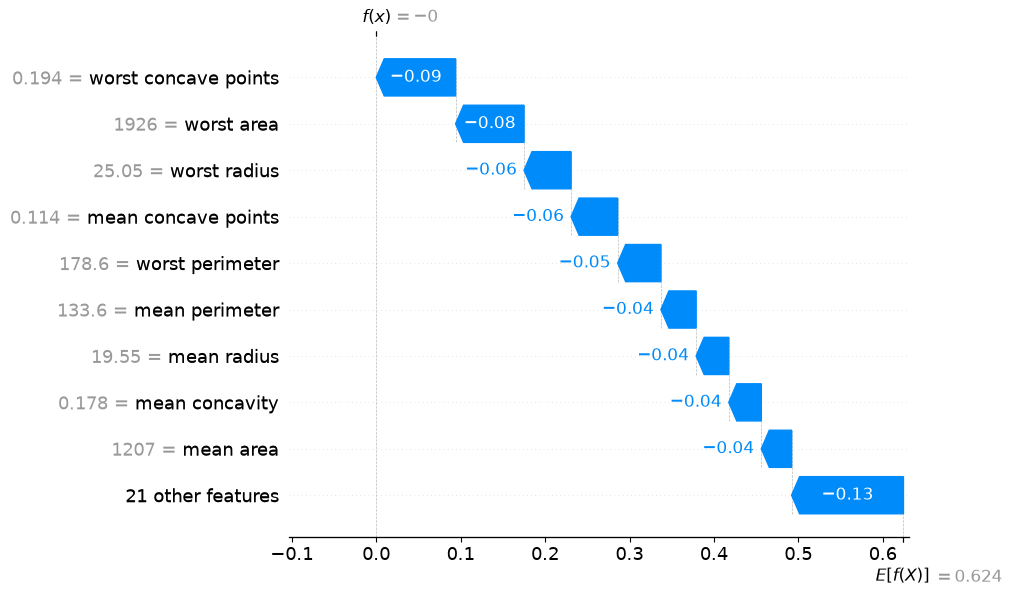

In [55]:
shap.plots.waterfall(
    shap_values[0, :, 1],
    max_display=10
)

## Interpretation of SHAP Waterfall Plot

The SHAP waterfall plot explains the prediction for a single patient by illustrating how individual features contributed to the final prediction.

For this patient, features such as **Worst Concave Points**, **Worst Area**, **Worst Radius**, and **Worst Perimeter** had the largest influence on the model's decision.

These features reduced the probability of the benign class, thereby increasing the likelihood of a malignant prediction.

The SHAP explanation is consistent with the global feature importance analysis, indicating that clinically relevant tumor characteristics played a major role in the model's prediction.